# Load and prepare all datasets

# 1. Data Sources & Provenance

### 1.1 Base Datasets (Raw)
The following datasets were used in their raw format directly from Kaggle and Zenodo. Click the Source ID to view the original repository. 

*(Note: The "Room Occupancy" dataset (DATA 1) was renamed locally to `room_conditions.csv` to match project conventions.)*

| ID | Dataset Focus | Relative Path | 
| :--- | :--- | :--- | 
| [DATA 1](https://www.kaggle.com/datasets/tombutton/roomoccupancy) | Room Occupancy | `data/raw/data_1/room_conditions.csv` | 
| [DATA 2](https://www.kaggle.com/datasets/colabsss/ai-iot-agile-teaching-dataset/data) | Agile Teaching | `data/raw//data_2/agile_teaching_dataset.csv` | 
| [DATA 3](https://www.kaggle.com/datasets/ziya07/environmental-design-iotml-dataset) | Environmental Design | `data/raw//data_3/environmental_design_dataset.csv` | 
| [DATA 4](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset/data) | Green Building | `data/raw//data_4/green_building_dataset.csv` | 
| [DATA 5](https://www.kaggle.com/datasets/ziya07/iot-based-environmental-dataset/data) | Univ. Mental Health | `data/raw//data_5/university_mental_health_iot_dataset.csv` | 
| [DATA 8](https://zenodo.org/records/18016442) | Smart Campus Comfort | `data/raw/data_8/smart-campus-comfort-data/1_room_measurements.csv` |

### 1.2 The KETI Smart Building Dataset (Interim)
[DATA 6 (Smart Building System)](https://www.kaggle.com/datasets/ranakrc/smart-building-system) originally consisted of 50+ individual CSV files distributed across multiple folders inside `data/raw//data_6/KETI/`. 

1. **Aggregation & Alignment:** Parsed Unix timestamps and merged the distributed, asynchronous sensor CSVs into a single time-aligned file.
2. **Physical Bound Filtering:** Applied conservative physical bounds to continuous sensors (e.g., CO2 strictly between 250–2000 ppm). Values outside these ranges were treated as sensor glitches and converted to nulls (pd.NA) prior to aggregation.
3. **Feature Engineering:** Binarized the Passive Infrared (PIR) motion sensor data. Values were normalized to standard boolean triggers (0 = vacant, 1 = occupied).
4. **Resampling:** Resampled the entire dataset to a standardized 1-minute frequency, applying statistical aggregations (`mean` for continuous sensors, `max` for boolean motion).
5. **Data Quality Tracking:** Missing values were deliberately preserved rather than imputed at this stage. Instead, observation-count columns (e.g., co2_observations) were generated to track data coverage and inform downstream imputation steps.

The final time-aligned data used for this analysis is located at: `data/interim/keti_1min_resampled.csv`.

### 1.3 The HomeCoach Dataset (Interim / Data 7)

[DATA 7 (HomeCoach)](https://zenodo.org/records/20098783) originally consisted of four separate CSV files split by year (2023, 2024, 2025, and 2026) located in `data/raw/DATA_7/`. 

1. **Concatenation:** Loaded and vertically merged the four disjointed yearly files into a single continuous dataframe.
2. **Timeline Standardization:** Parsed the raw string timestamps into strict Pandas `datetime` objects and sorted the entire dataset chronologically to ensure no overlapping or out-of-order rows.
3. **Identifier Assignment:** Injected a standard `id` column (`HomeCoach`) to ensure the dataset could seamlessly join with the other sources in our pipeline.

The final combined data used for this analysis is located at: `data/interim/HomeCoach_combined.csv`.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots to look clean and consistent
sns.set_theme(style='whitegrid')
plt.style.use("default")

# Adjust options for clear display of floating point numbers
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## Data 1

In [32]:
data_1 = pd.read_csv('../../data/raw/data_1/room_conditions.csv')
data_1.head()

,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,140,02/02/15 14:19,23.70,26.27,585.20,749.20,0.00,1
1,141,02/02/15 14:19,23.72,26.29,578.40,760.40,0.00,1
2,142,02/02/15 14:21,23.73,26.23,572.67,769.67,0.00,1
3,143,02/02/15 14:22,23.72,26.12,493.75,774.75,0.00,1
4,144,02/02/15 14:23,23.75,26.20,488.60,779.00,0.00,1


In [33]:
data_1 = data_1.drop(columns=['id','Occupancy', 'HumidityRatio'])
data_1 = data_1.rename(columns={'Temperature': 'temperature', 'Humidity': 'humidity', 'Light': 'light', 'CO2': 'co2', 'date':'timestamp'})
data_1.head()

,timestamp,temperature,humidity,light,co2
0,02/02/15 14:19,23.70,26.27,585.20,749.20
1,02/02/15 14:19,23.72,26.29,578.40,760.40
2,02/02/15 14:21,23.73,26.23,572.67,769.67
3,02/02/15 14:22,23.72,26.12,493.75,774.75
4,02/02/15 14:23,23.75,26.20,488.60,779.00


In [34]:
# Analyze the ranges of individual features
print("Data 1 Ranges:")
print(data_1.describe())

Data 1 Ranges:
       temperature  humidity    light      co2
count     2,665.00  2,665.00 2,665.00 2,665.00
mean         21.43     25.35   193.23   717.91
std           1.03      2.44   250.21   292.68
min          20.20     22.10     0.00   427.50
25%          20.65     23.26     0.00   466.00
50%          20.89     25.00     0.00   580.50
75%          22.36     26.86   442.50   956.33
max          24.41     31.47 1,697.25 1,402.25


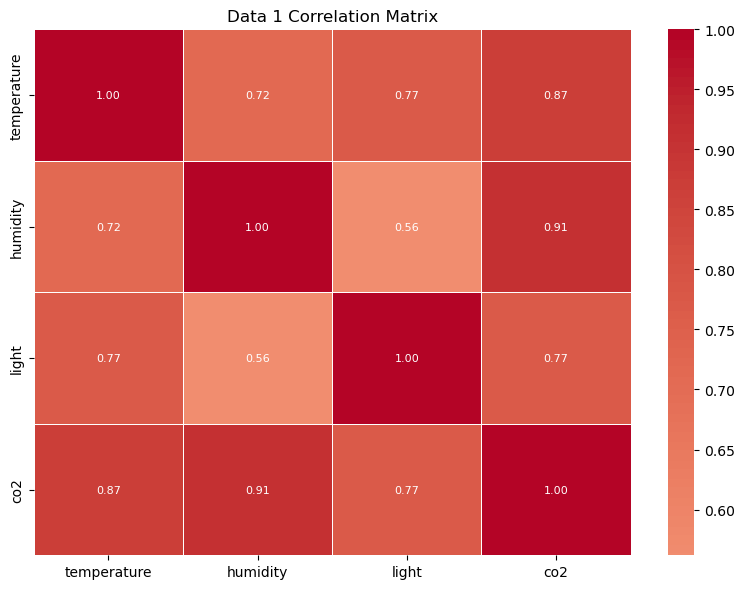

In [35]:
# Correlation matrix for Data 1 (numeric features)
data_1_numeric = data_1.select_dtypes(include=np.number)
if data_1_numeric.empty:
    print("Data 1 has no numeric columns for correlation.")
else:
    data_1_corr = data_1_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_1_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 1 Correlation Matrix")
    plt.tight_layout()
    plt.show()

Every 1-2 minutes

## Data 2

In [36]:
data_2 = pd.read_csv('../../data/raw//data_2/agile_teaching_dataset.csv')
data_2.head()

,student_id,timestamp,heart_rate,skin_temp,movement_level,focus_score,emotional_state,ambient_light,ambient_noise,temperature,humidity,board_interaction,learning_material_access,quiz_score,assignment_completion,participation_level,target
0,1047,2024-09-01 08:00:00,99,36.30,2.07,0.45,stressed,264,59,25.90,38.20,12,12,61,59,5,0
1,1008,2024-09-01 08:01:00,114,36.30,8.63,0.39,neutral,628,37,29.90,54.80,33,5,13,16,2,0
2,1068,2024-09-01 08:02:00,87,36.90,6.48,0.63,happy,772,69,21.60,50.70,18,4,91,94,0,1
3,1004,2024-09-01 08:03:00,113,37.90,4.68,0.84,neutral,621,37,26.60,65.80,19,8,7,61,8,1
4,1093,2024-09-01 08:04:00,70,37.60,9.47,0.68,happy,648,46,23.30,31.20,2,11,81,88,9,0


In [37]:
# We only take columns we need
data_2 = data_2[['timestamp', 'temperature', 'ambient_light', 'humidity', 'ambient_noise','focus_score', 'student_id']]
data_2 = data_2.rename(columns={'timestamp': 'timestamp', 'focus_score': 'score', 'ambient_light': 'light', 'ambient_noise': 'noise', 'temperature': 'temperature', 'humidity': 'humidity', 'student_id':'id'})
data_2.head()

,timestamp,temperature,light,humidity,noise,score,id
0,2024-09-01 08:00:00,25.90,264,38.20,59,0.45,1047
1,2024-09-01 08:01:00,29.90,628,54.80,37,0.39,1008
2,2024-09-01 08:02:00,21.60,772,50.70,69,0.63,1068
3,2024-09-01 08:03:00,26.60,621,65.80,37,0.84,1004
4,2024-09-01 08:04:00,23.30,648,31.20,46,0.68,1093


In [38]:
# Don't think about id's as math
data_2['id'] = data_2['id'].astype(str)

In [39]:
# Analyze the ranges of individual features
print("Data 2 Ranges:")
print(data_2.describe())

Data 2 Ranges:
       temperature    light  humidity    noise    score
count     3,500.00 3,500.00  3,500.00 3,500.00 3,500.00
mean         24.98   547.85     50.29    54.44     0.50
std           2.86   257.39     11.62    14.50     0.29
min          20.00   100.00     30.00    30.00     0.00
25%          22.50   322.75     40.00    42.00     0.26
50%          25.00   542.00     50.50    54.00     0.51
75%          27.50   774.00     60.50    67.00     0.75
max          30.00   999.00     70.00    79.00     1.00


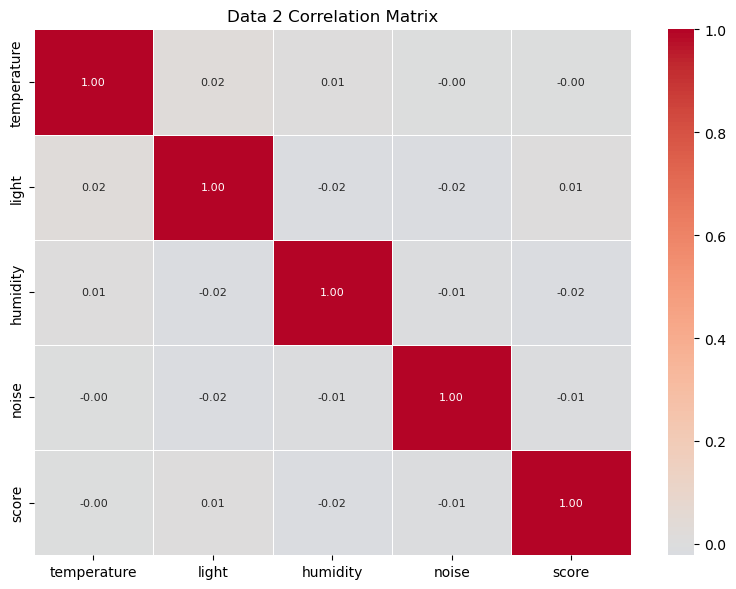

In [40]:
# Correlation matrix for Data 2 (numeric features)
data_2_numeric = data_2.select_dtypes(include=np.number)
if data_2_numeric.empty:
    print("Data 2 has no numeric columns for correlation.")
else:
    data_2_corr = data_2_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_2_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 2 Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [41]:
data_2 = data_2.sort_values(
    by=["id", "timestamp"],
    ascending=[True, True]
).reset_index(drop=True)

data_2

,timestamp,temperature,light,humidity,noise,score,id
0,2024-09-01 08:28:00,28.00,627,54.80,71,0.08,1000
1,2024-09-01 09:40:00,25.80,938,46.30,59,0.40,1000
2,2024-09-01 12:26:00,26.60,593,57.20,30,0.27,1000
3,2024-09-01 12:50:00,21.30,647,64.30,37,0.03,1000
4,2024-09-01 17:21:00,23.90,390,42.20,75,0.65,1000
...,...,...,...,...,...,...,...
3495,2024-09-03 07:58:00,25.60,674,52.60,60,0.84,1099
3496,2024-09-03 09:12:00,29.80,927,36.30,52,0.96,1099
3497,2024-09-03 11:00:00,26.90,266,35.40,70,0.70,1099
3498,2024-09-03 13:02:00,28.10,646,34.20,57,0.78,1099


Every app 2 hours

## Data 3

In [42]:
data_3 = pd.read_csv('../../data/raw//data_3/environmental_design_dataset.csv')
data_3.head()

,Timestamp,Sensor_ID,Zone,Temp,Humidity,CO2,PM25,Illuminance,Sound,PMV,PPD,DA,AAI,NDVI,Comfort_Score,AQI_Class
0,2024-01-01 00:00:00,S1,Room1,27.03,47.76,550.08,26.50,374.69,44.07,-0.23,9.61,37.47,0.44,0.59,0.92,Good
1,2024-01-01 00:00:00,S2,Room2,25.05,42.02,710.30,15.07,384.84,41.32,-0.13,14.61,38.48,0.41,0.33,0.96,Good
2,2024-01-01 00:00:00,S3,Room3,25.97,48.07,579.44,21.09,412.94,37.56,-0.01,9.20,41.29,0.38,0.34,1.00,Good
3,2024-01-01 01:00:00,S1,Room1,24.18,53.92,634.83,25.22,370.47,52.16,-0.45,16.92,37.05,0.52,0.60,0.85,Good
4,2024-01-01 01:00:00,S2,Room2,25.67,51.19,608.68,8.47,474.30,50.17,-0.17,8.37,47.43,0.50,0.70,0.94,Moderate


In [43]:
# We only take columns we need
data_3 = data_3[['Timestamp', 'Temp', 'Illuminance', 'Humidity', 'Sound','Comfort_Score', 'Zone', 'CO2']]
data_3 = data_3.rename(columns={'CO2': 'co2', 'Timestamp': 'timestamp', 'Temp': 'temperature', 'Illuminance': 'light', 'Humidity': 'humidity', 'Sound': 'noise', 'Comfort_Score': 'score', 'Zone':'id'})
data_3.head()

,timestamp,temperature,light,humidity,noise,score,id,co2
0,2024-01-01 00:00:00,27.03,374.69,47.76,44.07,0.92,Room1,550.08
1,2024-01-01 00:00:00,25.05,384.84,42.02,41.32,0.96,Room2,710.30
2,2024-01-01 00:00:00,25.97,412.94,48.07,37.56,1.00,Room3,579.44
3,2024-01-01 01:00:00,24.18,370.47,53.92,52.16,0.85,Room1,634.83
4,2024-01-01 01:00:00,25.67,474.30,51.19,50.17,0.94,Room2,608.68


In [44]:
# Analyze the ranges of individual features
print("Data 3 Ranges:")
print(data_3.describe())

Data 3 Ranges:
       temperature    light  humidity    noise    score      co2
count     6,480.00 6,480.00  6,480.00 6,480.00 6,480.00 6,480.00
mean         24.00   399.01     49.94    44.96     0.91   600.33
std           1.99    99.96      5.01     5.00     0.05    98.17
min          16.42    45.60     31.15    26.14     0.70   202.93
25%          22.68   331.95     46.45    41.66     0.87   534.25
50%          24.02   399.13     49.96    45.03     0.91   601.10
75%          25.36   466.02     53.34    48.26     0.94   666.93
max          32.38   760.86     68.87    65.59     1.00   970.94


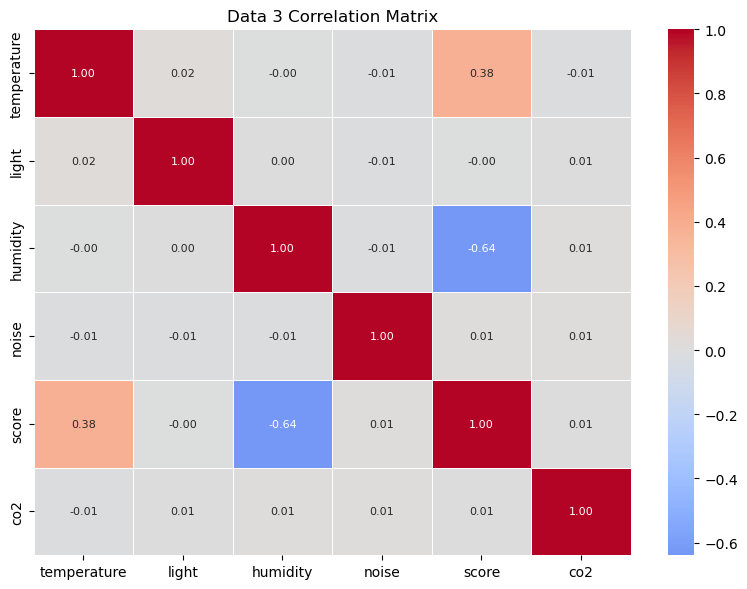

In [45]:
# Correlation matrix for Data 3 (numeric features)
data_3_numeric = data_3.select_dtypes(include=np.number)
if data_3_numeric.empty:
    print("Data 3 has no numeric columns for correlation.")
else:
    data_3_corr = data_3_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_3_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 3 Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [46]:
data_3 = data_3.sort_values(
    by=["id", "timestamp"],
    ascending=[True, True]
).reset_index(drop=True)

data_3

,timestamp,temperature,light,humidity,noise,score,id,co2
0,2024-01-01 00:00:00,27.03,374.69,47.76,44.07,0.92,Room1,550.08
1,2024-01-01 01:00:00,24.18,370.47,53.92,52.16,0.85,Room1,634.83
2,2024-01-01 02:00:00,24.47,436.37,58.11,48.10,0.85,Room1,618.23
3,2024-01-01 03:00:00,23.43,447.70,53.05,41.93,0.83,Room1,540.10
4,2024-01-01 04:00:00,22.93,462.68,52.89,46.96,0.89,Room1,772.61
...,...,...,...,...,...,...,...,...
6475,2024-03-30 19:00:00,24.95,283.67,53.24,45.32,0.88,Room3,346.75
6476,2024-03-30 20:00:00,24.37,353.90,50.79,42.98,0.89,Room3,675.60
6477,2024-03-30 21:00:00,21.97,168.86,50.55,46.63,0.86,Room3,518.98
6478,2024-03-30 22:00:00,24.80,259.22,47.16,42.90,0.94,Room3,748.50


Every 1hr

## Data 4

In [47]:
data_4 = pd.read_csv('../../data/raw//data_4/green_building_dataset.csv')
data_4.head()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.49,43.62,554.35,432.12,30.96,24.44,22.67,540.77,0.33,47.82,34.28,18.92,21.25,327.05,29.35,26,0,39.94,0.23
1,29.41,32.87,466.38,221.97,68.62,-1.40,50.09,699.96,5.05,43.36,23.38,17.73,18.00,144.86,26.65,7,0,24.99,0.00
2,26.78,46.39,"1,850.56",566.56,38.55,5.90,24.42,828.11,12.98,36.38,2.79,19.93,39.10,493.65,24.21,43,1,39.68,0.00
3,25.18,42.45,663.71,201.35,32.20,29.82,75.24,791.54,0.65,3.77,45.93,17.37,37.27,475.09,6.28,3,1,52.68,0.00
4,19.87,57.08,"1,705.06",940.59,62.68,18.79,57.07,882.61,6.43,2.45,49.02,21.65,45.26,287.22,4.69,20,3,48.82,0.00


In [48]:
# We only take columns we need
data_4 = data_4[['indoor_temperature', 'indoor_lighting', 'indoor_humidity', 'indoor_noise','predicted_comfort_index']]
data_4 = data_4.rename(columns={'indoor_temperature': 'temperature', 'indoor_humidity': 'humidity', 'indoor_lighting': 'light', 'indoor_noise': 'noise', 'predicted_comfort_index': 'score'})
data_4.head()

,temperature,light,humidity,noise,score
0,22.49,432.12,43.62,30.96,0.23
1,29.41,221.97,32.87,68.62,0.00
2,26.78,566.56,46.39,38.55,0.00
3,25.18,201.35,42.45,32.20,0.00
4,19.87,940.59,57.08,62.68,0.00


keeping zone to be able to later differentiate between sessions

In [49]:
# Analyze the ranges of individual features
print("Data 4 Ranges:")
print(data_4.describe())

Data 4 Ranges:
       temperature    light  humidity    noise    score
count     2,400.00 2,400.00  2,400.00 2,400.00 2,400.00
mean         23.98   537.94     49.79    55.16     0.00
std           3.49   254.25     11.51    14.54     0.01
min          18.02   100.05     30.00    30.01     0.00
25%          20.90   325.96     39.94    42.56     0.00
50%          24.09   532.78     49.70    55.09     0.00
75%          26.99   747.54     59.68    67.98     0.00
max          30.00   999.01     69.98    79.98     0.23


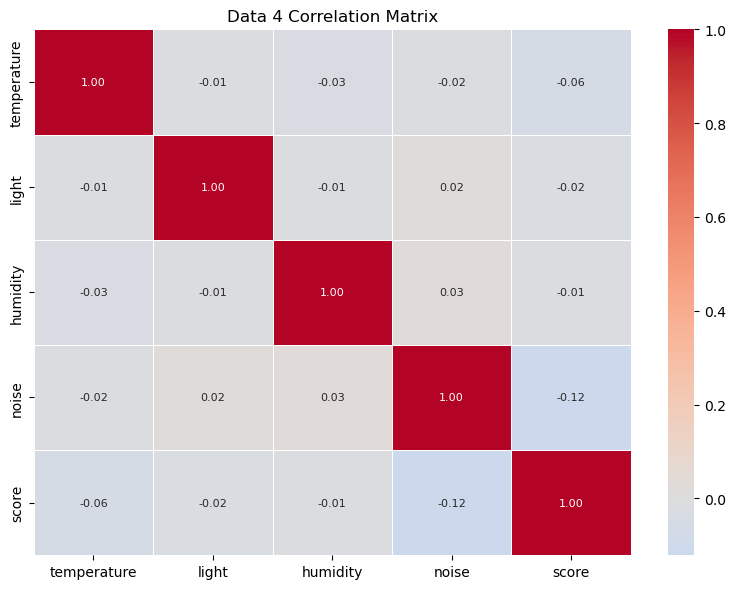

In [50]:
# Correlation matrix for Data 4 (numeric features)
data_4_numeric = data_4.select_dtypes(include=np.number)
if data_4_numeric.empty:
    print("Data 4 has no numeric columns for correlation.")
else:
    data_4_corr = data_4_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_4_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 4 Correlation Matrix")
    plt.tight_layout()
    plt.show()

## Data 5

In [51]:
data_5 = pd.read_csv('../../data/raw//data_5/university_mental_health_iot_dataset.csv')
data_5.head()

,timestamp,location_id,temperature_celsius,humidity_percent,air_quality_index,noise_level_db,lighting_lux,crowd_density,stress_level,sleep_hours,mood_score,mental_health_status
0,2024-05-01 08:00:00,104,24.33,62.99,67,54.43,323.02,45,23,7.22,2.30,0
1,2024-05-01 08:15:00,105,26.18,52.48,77,62.34,412.21,17,54,5.02,1.70,1
2,2024-05-01 08:30:00,103,25.44,55.74,120,51.97,386.97,35,39,4.96,2.90,0
3,2024-05-01 08:45:00,105,24.67,71.48,131,54.66,339.06,25,39,8.24,0.00,0
4,2024-05-01 09:00:00,105,21.63,61.13,81,60.62,341.46,36,18,6.61,3.00,0


In [52]:
# We only take columns we need
data_5 = data_5[['location_id', 'timestamp', 'temperature_celsius', 'humidity_percent', 'noise_level_db', 'lighting_lux']]
data_5 = data_5.rename(columns={'temperature_celsius': 'temperature', 'humidity_percent': 'humidity', 'lighting_lux': 'light', 'noise_level_db': 'noise', 'predicted_comfort_index': 'score', 'location_id':'id'})
data_5.head()

,id,timestamp,temperature,humidity,noise,light
0,104,2024-05-01 08:00:00,24.33,62.99,54.43,323.02
1,105,2024-05-01 08:15:00,26.18,52.48,62.34,412.21
2,103,2024-05-01 08:30:00,25.44,55.74,51.97,386.97
3,105,2024-05-01 08:45:00,24.67,71.48,54.66,339.06
4,105,2024-05-01 09:00:00,21.63,61.13,60.62,341.46


keeping zone to be able to later differentiate between sessions

In [53]:
# Don't think about id's as math
data_5['id'] = data_5['id'].astype(str)

In [54]:
# Analyze the ranges of individual features
print("Data 5 Ranges:")
print(data_5.describe())

Data 5 Ranges:
       temperature  humidity    noise    light
count     1,000.00  1,000.00 1,000.00 1,000.00
mean         24.21     60.19    54.72   301.50
std           3.01      9.75    10.05    48.87
min          15.24     29.80    24.54   155.22
25%          22.18     53.73    47.85   267.39
50%          24.17     60.05    54.78   300.47
75%          26.13     66.73    61.79   334.17
max          33.58     91.38    85.93   502.63


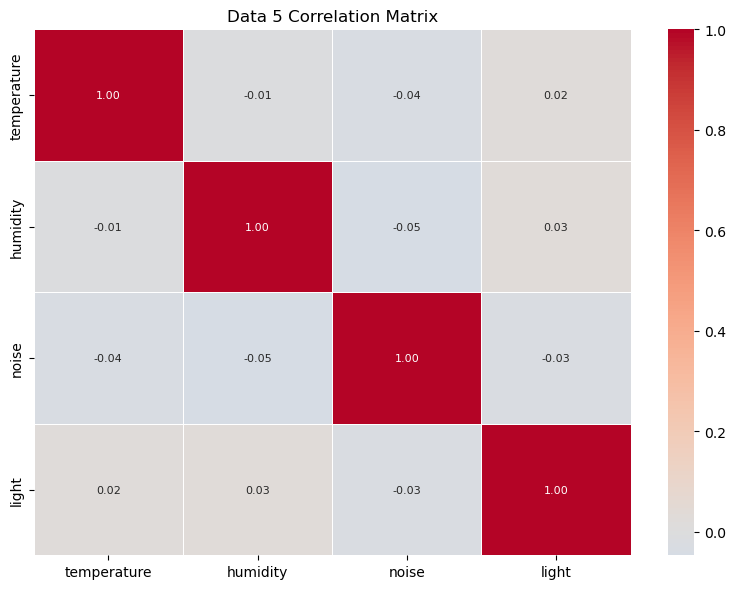

In [55]:
# Correlation matrix for Data 5 (numeric features)
data_5_numeric = data_5.select_dtypes(include=np.number)
if data_5_numeric.empty:
    print("Data 5 has no numeric columns for correlation.")
else:
    data_5_corr = data_5_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_5_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 5 Correlation Matrix")
    plt.tight_layout()
    plt.show()

# Data 6

In [56]:
data_6 = pd.read_csv('../../data/interim/keti_1min_resampled.csv', dtype={'room': str})
data_6['timestamp'] = pd.to_datetime(data_6['timestamp'])
data_6.head()

,room,timestamp,co2,humidity,light,temperature,pir,co2_observations,humidity_observations,light_observations,temperature_observations,pir_observations
0,413,2013-08-23 23:05:00,494.73,45.33,96.56,23.93,0.00,11,9,9,9,7
1,413,2013-08-23 23:06:00,496.67,45.33,96.83,23.94,0.00,12,12,12,12,6
2,413,2013-08-23 23:07:00,498.92,45.33,97.33,23.94,0.00,12,12,12,12,6
3,413,2013-08-23 23:08:00,504.17,45.31,97.08,23.95,0.00,12,12,12,12,6
4,413,2013-08-23 23:09:00,499.50,45.31,97.42,23.96,0.00,12,12,12,12,6


In [57]:
# Analyze the ranges of individual features
print("Data 6 Ranges:")
print(data_6.describe())

data_6


Data 6 Ranges:
                           timestamp        co2   humidity      light  \
count                         604891 526,193.00 548,600.00 548,600.00   
mean   2013-08-28 02:14:45.563977472     421.63      56.75      82.28   
min              2013-08-23 15:00:00     250.00      42.12       0.00   
25%              2013-08-25 23:56:00     361.17      53.98       3.50   
50%              2013-08-28 02:02:00     414.75      57.01       4.33   
75%              2013-08-30 04:27:00     464.92      59.73      30.17   
max              2013-09-01 06:58:00   1,669.50      71.88   2,393.67   
std                              NaN      91.09       4.30     309.00   

       temperature        pir  co2_observations  humidity_observations  \
count   548,602.00 588,616.00        604,891.00             604,891.00   
mean         23.16       0.06             10.37                  10.86   
min          20.18       0.00              0.00                   0.00   
25%          22.53       0.00  

,room,timestamp,co2,humidity,light,temperature,pir,co2_observations,humidity_observations,light_observations,temperature_observations,pir_observations
0,413,2013-08-23 23:05:00,494.73,45.33,96.56,23.93,0.00,11,9,9,9,7
1,413,2013-08-23 23:06:00,496.67,45.33,96.83,23.94,0.00,12,12,12,12,6
2,413,2013-08-23 23:07:00,498.92,45.33,97.33,23.94,0.00,12,12,12,12,6
3,413,2013-08-23 23:08:00,504.17,45.31,97.08,23.95,0.00,12,12,12,12,6
4,413,2013-08-23 23:09:00,499.50,45.31,97.42,23.96,0.00,12,12,12,12,6
...,...,...,...,...,...,...,...,...,...,...,...,...
604886,776,2013-09-01 06:54:00,NaN,NaN,NaN,NaN,0.00,0,0,0,0,6
604887,776,2013-09-01 06:55:00,NaN,NaN,NaN,NaN,0.00,0,0,0,0,6
604888,776,2013-09-01 06:56:00,NaN,NaN,NaN,NaN,0.00,0,0,0,0,6
604889,776,2013-09-01 06:57:00,NaN,NaN,NaN,NaN,0.00,0,0,0,0,6


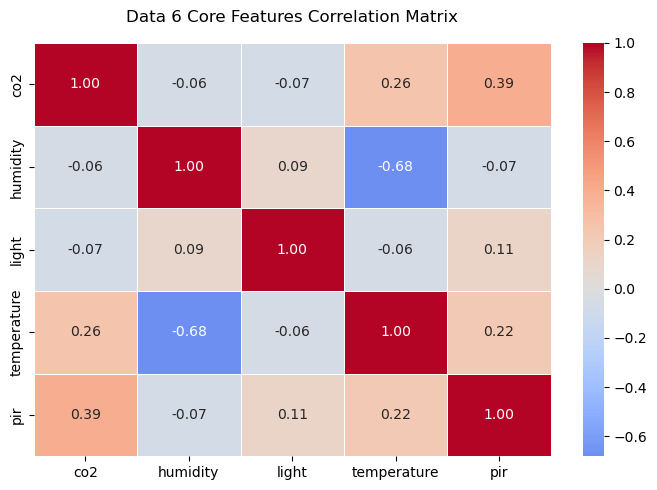

In [58]:
# Select numeric columns
data_6_numeric = data_6.select_dtypes(include=np.number)

# --- THE FIX: Filter out any column containing the word "observations" ---
cols_to_drop = [col for col in data_6_numeric.columns if "observations" in col]
data_6_clean = data_6_numeric.drop(columns=cols_to_drop)
# ------------------------------------------------------------------------

if data_6_clean.empty:
    print("Data 6 has no numeric columns for correlation.")
else:
    data_6_corr = data_6_clean.corr()
    plt.figure(figsize=(7, 5)) # Slightly smaller size fits 5x5 perfectly
    sns.heatmap(
        data_6_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 10}, # Increased size since there's more room now
    )
    plt.title("Data 6 Core Features Correlation Matrix", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

In [59]:
# We only take columns we need
data_6 = data_6[['room', 'timestamp', 'temperature', 'humidity', 'light', 'co2']]
data_6 = data_6.rename(columns={'room': 'id'})
data_6.head()

,id,timestamp,temperature,humidity,light,co2
0,413,2013-08-23 23:05:00,23.93,45.33,96.56,494.73
1,413,2013-08-23 23:06:00,23.94,45.33,96.83,496.67
2,413,2013-08-23 23:07:00,23.94,45.33,97.33,498.92
3,413,2013-08-23 23:08:00,23.95,45.31,97.08,504.17
4,413,2013-08-23 23:09:00,23.96,45.31,97.42,499.50


# Data 7

In [60]:
data_7 = pd.read_csv('../../data/interim/HomeCoach_combined.csv')
data_7['timestamp'] = pd.to_datetime(data_7['timestamp'])

display(data_7.head())

,id,timestamp,Temperature,Humidity,CO2,Noise,Pressure
0,HomeCoach,2023-03-04 09:12:50,17.70,56,2305,67,"1,006.60"
1,HomeCoach,2023-03-04 09:17:50,17.90,56,2250,73,"1,006.60"
2,HomeCoach,2023-03-04 09:22:50,18.30,57,2286,77,"1,006.40"
3,HomeCoach,2023-03-04 09:27:50,18.90,57,2266,58,"1,006.40"
4,HomeCoach,2023-03-04 09:32:50,19.10,57,2238,54,"1,006.30"


In [61]:
# Select only the columns we want (excluding Pressure)
data_7 = data_7[['id', 'timestamp', 'Temperature', 'Humidity', 'CO2', 'Noise']]

In [62]:
# 3. Rename the remaining capital columns to lowercase
data_7 = data_7.rename(columns={
    'Temperature': 'temperature', 
    'Humidity': 'humidity', 
    'CO2': 'co2',
    'Noise': 'noise'
})

In [63]:
# Analyze the ranges of individual features
print("Data 7 Ranges:")
display(data_7.describe())

Data 7 Ranges:


,timestamp,temperature,humidity,co2,noise
count,311692,"311,692.00","311,692.00","311,692.00","311,692.00"
mean,2024-10-13 12:43:32.290777600,22.11,51.44,927.02,40.55
min,2023-03-04 09:12:50,15.60,24.00,329.00,31.00
25%,2024-01-04 04:26:16,19.40,47.00,546.00,32.00
50%,2024-10-14 02:11:35,21.00,52.00,773.00,37.00
75%,2025-07-25 16:41:08,24.90,56.00,"1,220.00",46.00
max,2026-05-06 15:47:49,31.60,72.00,"5,000.00",83.00
std,NaN,3.44,6.44,463.47,9.55


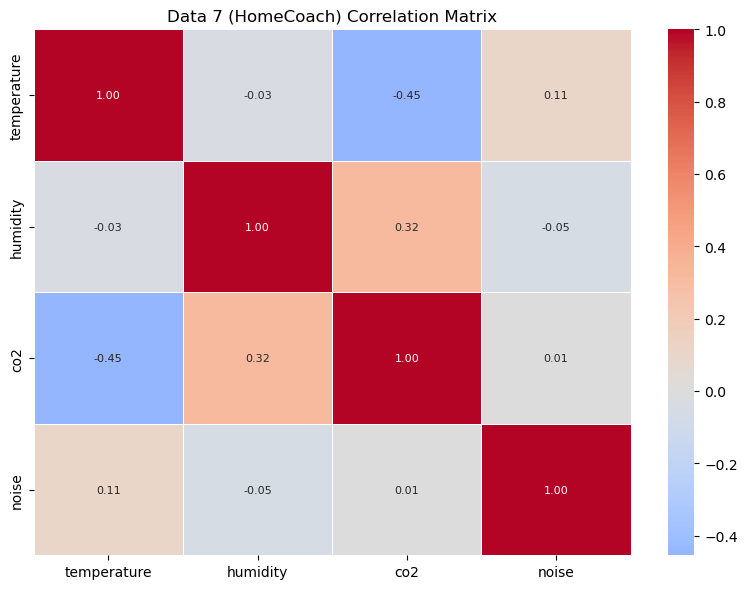

In [64]:
# 3. Correlation matrix for Data 7 (numeric features)
data_7_numeric = data_7.select_dtypes(include=np.number)
if data_7_numeric.empty:
    print("Data 7 has no numeric columns for correlation.")
else:
    data_7_corr = data_7_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_7_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 7 (HomeCoach) Correlation Matrix")
    plt.tight_layout()
    plt.show()

# Data 8

In [65]:
data_8 = pd.read_csv('../../data/raw/data_8/smart-campus-comfort-data/1_room_measurements.csv')
data_8['timestamp'] = pd.to_datetime(data_8['timestamp'])
data_8.head()

,timestamp,sensorId,room,temperature,humidity,noise,pressure,CO2
0,2025-09-15 00:00:03+00:00,70:ee:50:96:6b:50,Room 2.12,24.40,59.00,38.00,"1,018.70",413.00
1,2025-09-15 00:05:05+00:00,70:ee:50:96:6b:50,Room 2.12,24.50,59.00,39.00,"1,018.70",418.00
2,2025-09-15 00:10:08+00:00,70:ee:50:96:6b:50,Room 2.12,24.40,59.00,39.00,"1,018.70",421.00
3,2025-09-15 00:15:11+00:00,70:ee:50:96:6b:50,Room 2.12,24.40,59.00,38.00,"1,018.70",413.00
4,2025-09-15 00:20:14+00:00,70:ee:50:96:6b:50,Room 2.12,24.40,59.00,38.00,"1,018.80",413.00


In [66]:
# We drop 'sensorId' and 'pressure' to match the core features of Datasets 1-7
data_8 = data_8[['room', 'timestamp', 'temperature', 'humidity', 'noise', 'CO2']]

# Rename 'room' to 'id' and 'CO2' to lowercase 'co2' so the graphs overlap perfectly!
data_8 = data_8.rename(columns={
    'room': 'id',
    'CO2': 'co2'
})

print("Data 8 (Smart Campus Raw) Ranges:")
display(data_8.describe())

Data 8 (Smart Campus Raw) Ranges:


,temperature,humidity,noise,co2
count,"108,917.00","108,929.00","108,900.00","108,926.00"
mean,21.67,48.20,49.33,540.13
std,2.69,8.55,9.58,157.25
min,10.20,24.00,32.00,333.00
25%,20.60,42.00,44.75,426.00
50%,21.70,48.00,50.00,489.00
75%,23.50,54.00,54.00,609.00
max,33.50,70.00,79.00,"3,181.00"


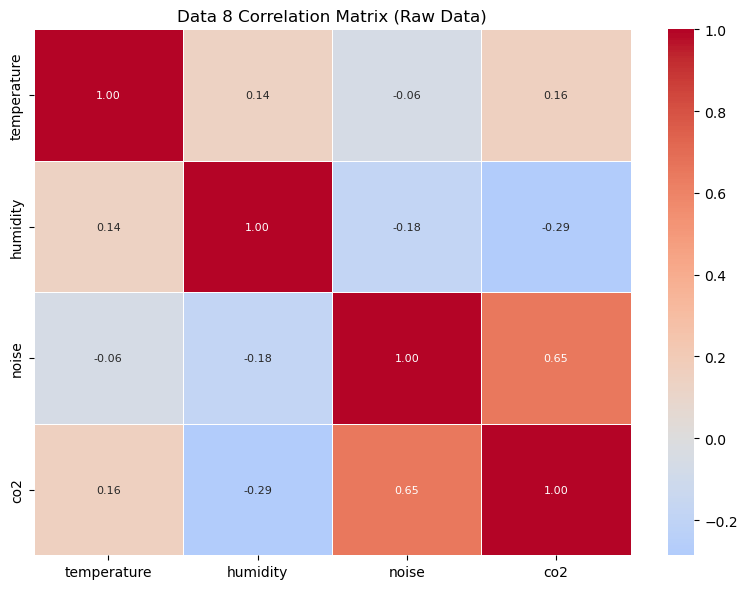

In [67]:
# 3. Correlation matrix for Data 8
data_8_numeric = data_8.select_dtypes(include=np.number)
if data_8_numeric.empty:
    print("Data 8 has no numeric columns for correlation.")
else:
    data_8_corr = data_8_numeric.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data_8_corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Data 8 Correlation Matrix (Raw Data)")
    plt.tight_layout()
    plt.show()

In [68]:
datasets = {
    "Data 1": data_1,
    "Data 2": data_2,
    "Data 3": data_3,
    "Data 4": data_4,
    "Data 5": data_5,
    "Data 6": data_6, 
    "Data 7": data_7,
    "Data 8": data_8 
}

all_columns = sorted(set().union(*(df.columns for df in datasets.values())))

presence = pd.DataFrame(
    {
        name: [col in df.columns for col in all_columns]
        for name, df in datasets.items()
    },
    index=all_columns
)

presence["Count"] = presence.sum(axis=1)

# Updated mapping since we now have 7 datasets
presence["Sharedness"] = presence["Count"].map({
    7: "🟢 shared by all",
    6: "🟡 shared by most",
    5: "🟡 shared by most",
    4: "🟠 shared by some", 
    3: "🟠 shared by some",
    2: "🔴 uncommon",
    1: "⚫ unique",
})

presence = presence.sort_values(
    by=["Count", "Sharedness"],
    ascending=[False, True]
)

pretty_presence = presence.copy()

for name in datasets:
    pretty_presence[name] = pretty_presence[name].map({
        True: "✅",
        False: "—"
    })

display(pretty_presence)

,Data 1,Data 2,Data 3,Data 4,Data 5,Data 6,Data 7,Data 8,Count,Sharedness
humidity,✅,✅,✅,✅,✅,✅,✅,✅,8,NaN
temperature,✅,✅,✅,✅,✅,✅,✅,✅,8,NaN
timestamp,✅,✅,✅,—,✅,✅,✅,✅,7,🟢 shared by all
id,—,✅,✅,—,✅,✅,✅,✅,6,🟡 shared by most
light,✅,✅,✅,✅,✅,✅,—,—,6,🟡 shared by most
noise,—,✅,✅,✅,✅,—,✅,✅,6,🟡 shared by most
co2,✅,—,✅,—,—,✅,✅,✅,5,🟡 shared by most
score,—,✅,✅,✅,—,—,—,—,3,🟠 shared by some


,Rows 📏,Columns 📚,Missing values ❓
Data 1,2665,5,0
Data 2,3500,7,0
Data 3,6480,8,0
Data 4,2400,5,0
Data 5,1000,6,0
Data 6,604891,6,247569
Data 7,311692,6,0
Data 8,108941,6,92


,Dataset,Feature,Min,Median,Mean,Max,Std
0,Data 1,co2,427.50,580.50,717.91,"1,402.25",292.68
1,Data 3,co2,202.93,601.10,600.33,970.94,98.17
2,Data 6,co2,250.00,414.75,421.63,"1,669.50",91.09
3,Data 7,co2,329.00,773.00,927.02,"5,000.00",463.47
4,Data 8,co2,333.00,489.00,540.13,"3,181.00",157.25
5,Data 1,humidity,22.10,25.00,25.35,31.47,2.44
6,Data 2,humidity,30.00,50.50,50.29,70.00,11.62
7,Data 3,humidity,31.15,49.96,49.94,68.87,5.01
8,Data 4,humidity,30.00,49.70,49.79,69.98,11.51
9,Data 5,humidity,29.80,60.05,60.19,91.38,9.75


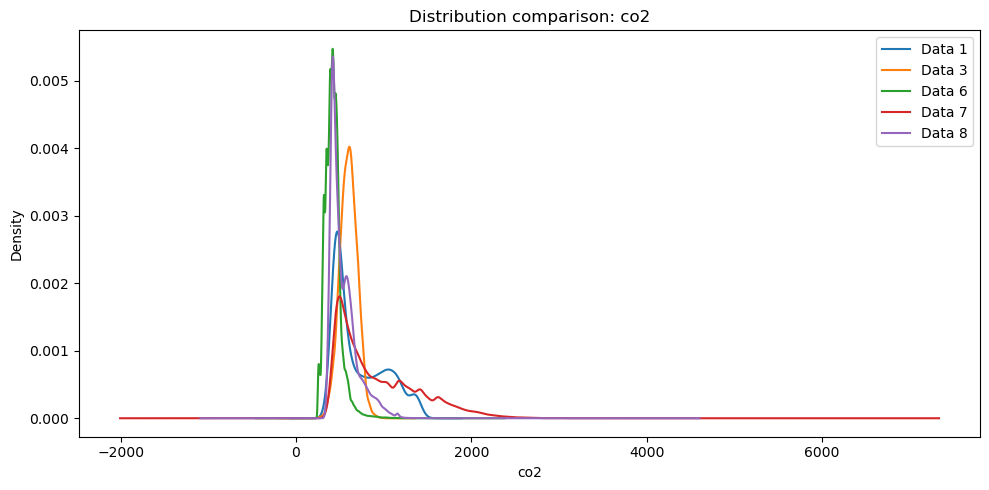

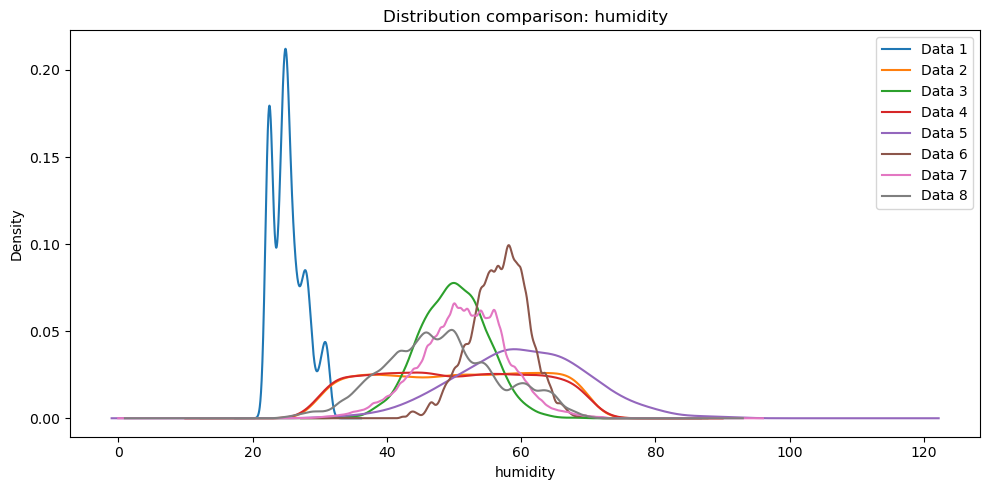

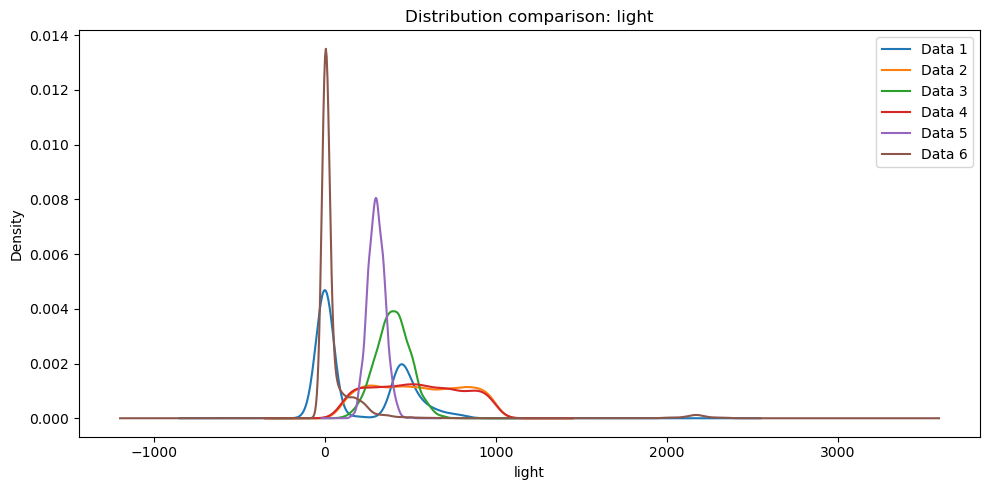

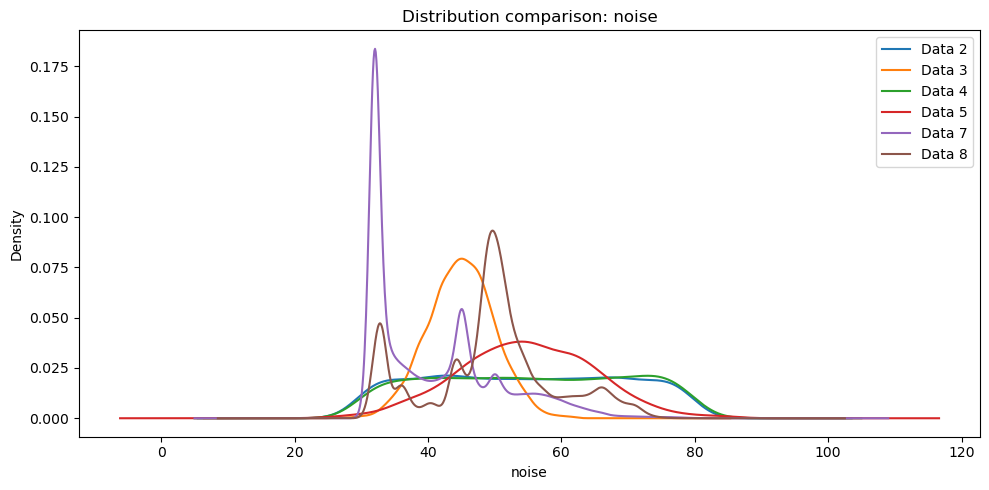

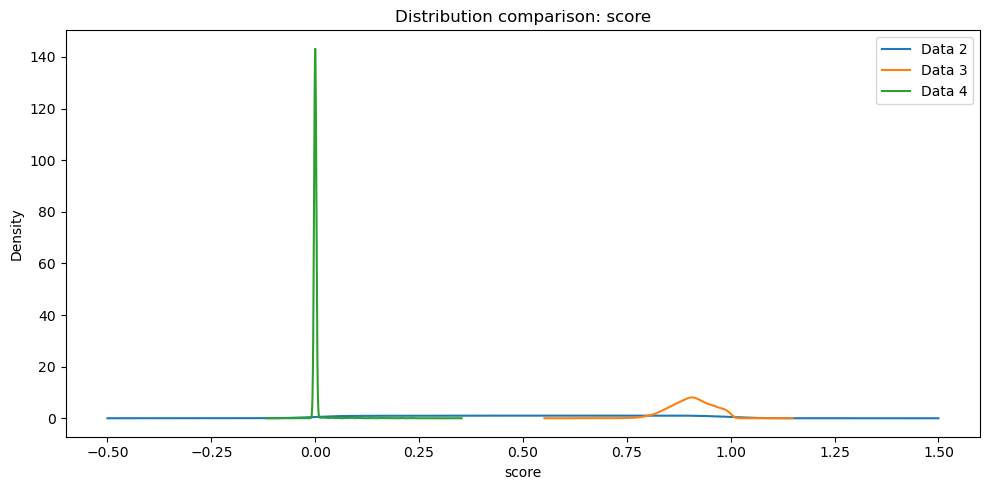

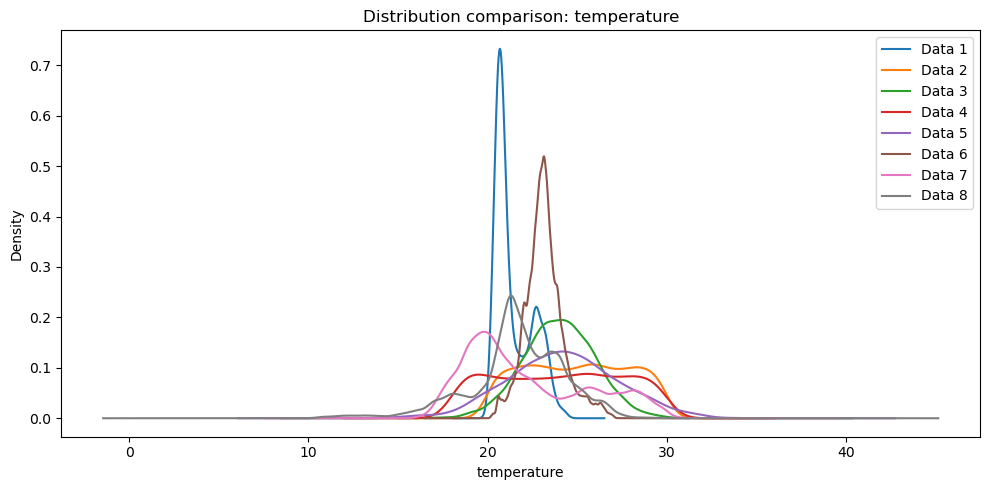

In [69]:
# --------------------------------------------------
# 1. Quick structural overview
# --------------------------------------------------
overview = pd.DataFrame({
    name: {
        "Rows 📏": df.shape[0],
        "Columns 📚": df.shape[1],
        "Missing values ❓": df.isna().sum().sum()
    }
    for name, df in datasets.items()
}).T

display(overview)

# --------------------------------------------------
# 2. Numeric feature comparison
# --------------------------------------------------
numeric_summary = []

for dataset_name, df in datasets.items():
    numeric_df = df.select_dtypes(include=np.number)

    for column in numeric_df.columns:
        numeric_summary.append({
            "Dataset": dataset_name,
            "Feature": column,
            "Min": numeric_df[column].min(),
            "Median": numeric_df[column].median(),
            "Mean": numeric_df[column].mean(),
            "Max": numeric_df[column].max(),
            "Std": numeric_df[column].std(),
        })

numeric_summary = pd.DataFrame(numeric_summary)

display(
    numeric_summary.sort_values(
        by=["Feature", "Dataset"]
    ).reset_index(drop=True)
)

# --------------------------------------------------
# 3. Visual anomaly detection (KDE Plots)
# --------------------------------------------------
numeric_features = sorted(set(
    col
    for df in datasets.values()
    for col in df.select_dtypes(include=np.number).columns
))

for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    found = False

    for name, df in datasets.items():
        if feature in df.columns and df[feature].dtype in [np.float64, np.int64]:
            # Dropna is important so the KDE doesn't break on missing data
            df[feature].dropna().plot(
                kind="kde",
                label=name
            )
            found = True

    if found:
        plt.title(f"Distribution comparison: {feature}")
        plt.xlabel(feature)
        plt.legend()
        plt.tight_layout()
        plt.show()

Data 1, 3, 6 looks very normal (normal as of distribution and stuff). Data 2 and 4 is highly suspicious with very even distributions. Data 5 corelation matrix is not the best.

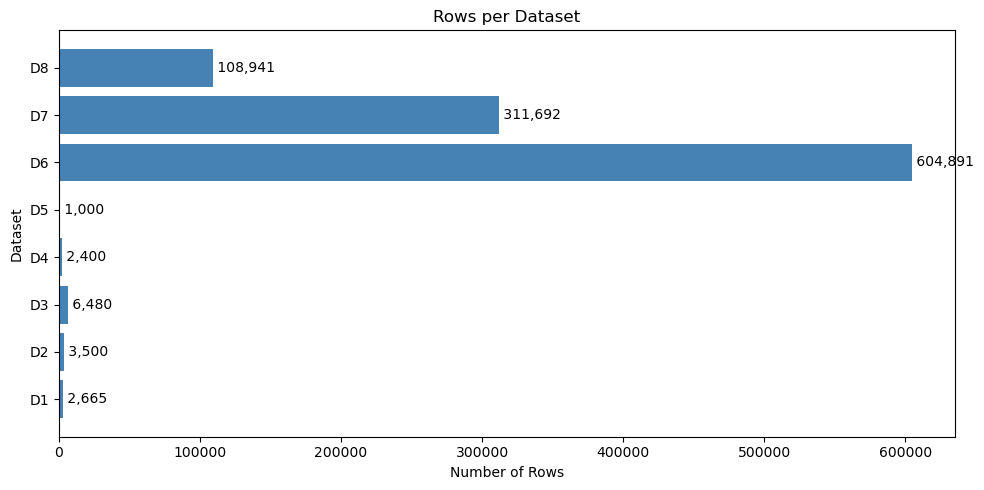

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# The dataset names are currently the index of your 'overview' dataframe
# Let's format them into the "D1", "D2" short names
short_names = overview.index.str.replace("Data ", "D", regex=False)

# Extract the row counts
row_counts = overview["Rows 📏"]

# Create the horizontal bar chart
# We can add a nice color like 'skyblue' or 'steelblue'
bars = plt.barh(short_names, row_counts, color='steelblue')

# Add your labels and title
plt.xlabel("Number of Rows")
plt.ylabel("Dataset")
plt.title("Rows per Dataset")

# Bonus: Add the exact numbers at the end of each bar!
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                               # X position (end of the bar)
        bar.get_y() + bar.get_height() / 2,  # Y position (center of the bar)
        f' {int(width):,}',                  # Text (formatted with commas, e.g., 1,000)
        va='center'                          # Vertically align to the center
    )

plt.tight_layout()
plt.show()

## End of Pre-Merge Exploratory Data Analysis

By looking at the above, we've successfully standardized the columns and chosen the distributions of the datasets we want to keep (Data 1, 6, 7, and 8). 

**Next Step: The Mega-Merge Pipeline**
Instead of trying to merge hundreds of thousands of rows in a Jupyter Notebook, we have written an optimized Python pipeline script (`build_unified_environment_dataset.py`). 

To generate the final dataset, run the following command in the terminal:
`python build_unified_environment_dataset.py`

This script will dynamically loop through our selected datasets, align their timestamps, assign session IDs, and output `unified_environment_focus_dataset.csv`. Once that script is run, proceed to **Notebook 3: Unified Dataset Analysis** to analyze the final merged result.